# GMM Mistuning Identification (matches GMM_Tuned.m / GMM_BladeSmallMistuned.m / GMM_DiskSmallMistuned.m)

This follows the same reduction technique as the original MATLAB GMM code:
a real Fourier matrix (`RFM`) combines block-diagonal blade CB modes and
disk cyclic modes into the transformation matrix `T` at each sector, and
`M_ROM = sum(T' * M * T)`, `K_ROM = sum(T' * K * T)` over all sectors, same
as `GMM_Tuned.m`. Stiffness mistuning is added the same way as
`GMM_BladeSmallMistuned.m` / `GMM_DiskSmallMistuned.m`: a `Tdelta` matrix
per sector, weighted by that sector's mistuning value and summed in.

**Real data**: normally `StiffMatrix`/`MassMatrix` (combined sector),
`StiffMatrix_D`/`MassMatrix_D` (disk-only, for `K_cc1`),
`StiffMatrix_B`/`MassMatrix_B` (blade-only, for `K_cc2`), node lists, blade
CB modes (`B_Phi`/`B_FREQ`), and disk cyclic modes (`DPhiBLKD`) all come
from ANSYS exports, exactly like the MATLAB scripts load them. Since those
files aren't available here, this notebook builds small synthetic stand-ins
with the same variable names/shapes so the pipeline runs end-to-end --
swap the "synthetic sector data" cell for your real loaded matrices and
everything downstream is unchanged.

**Validation note**: this demonstrates the reduction pipeline runs; it
does not re-derive or independently verify the GMM method itself (that's
your published, validated method). Check GMM vs. full FE frequencies with
your real data the same way your MATLAB scripts already do
(`Load_Phi('.../FullStage_..._Modes', ...)` + `Freq_Test`/`Error_ROM`).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh, solve
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

np.random.seed(0)

## 1. Real Fourier matrix (`real_fourier_matrix.m` equivalent)

In [2]:
def real_fourier_matrix(N):
    """N x N orthogonal real cyclic-symmetry Fourier matrix. Row = sector,
    column = harmonic (nodal diameter 0, then cos/sin pairs for 1..N/2-1,
    then Nyquist if N is even). RFM(i,:) is what GMM_Tuned.m calls
    "A = sparse(RFM(i,:))" for sector i."""
    n = np.arange(N)
    cols = [np.ones(N) / np.sqrt(N)]
    d = 1
    while d < N / 2:
        theta = 2 * np.pi * d * n / N
        cols.append(np.sqrt(2 / N) * np.cos(theta))
        cols.append(np.sqrt(2 / N) * np.sin(theta))
        d += 1
    if N % 2 == 0:
        cols.append(((-1.0) ** n) / np.sqrt(N))
    return np.array(cols).T

## 2. Sector data

`StiffMatrix`/`MassMatrix` (combined disk+blade+contact, one sector),
`StiffMatrix_D`/`MassMatrix_D` (disk only, no blade -- gives `K_cc1`),
`StiffMatrix_B`/`MassMatrix_B` (blade only -- gives `K_cc2`), same as the
MATLAB scripts. DOF order within each: `[D_DOF, C_DOF, B_DOF]` for the
combined model matches `K_dd, K_cd, K_cb, K_bb`.

Replace this cell with your real loaded matrices (e.g. via
`scipy.io.loadmat`) to run on real data -- everything below only uses the
variable names defined here.

In [3]:
# --- synthetic sector data (replace with your real ANSYS-exported matrices) ---
# local dof order: 0=L, 1=Id1, 2=Id2, 3=R, 4=C, 5=B  (disk ring boundary,
# two disk-interior masses, contact, blade)
k1, k2, k3, k4, k5, k6 = 5.0e5, 4.3e5, 3.7e5, 3.0e5, 4.0e5, 2.0e5
m_L, m_1, m_2, m_R, m_C, m_B = 0.05, 0.8, 0.9, 0.05, 0.02, 0.3

K_full = np.zeros((6, 6))
M_full = np.diag([m_L, m_1, m_2, m_R, m_C, m_B])

def add_spring(K, i, j, k):
    K[i, i] += k
    K[j, j] += k
    K[i, j] -= k
    K[j, i] -= k

add_spring(K_full, 0, 1, k1)  # L-Id1
add_spring(K_full, 1, 2, k2)  # Id1-Id2
add_spring(K_full, 2, 3, k3)  # Id2-R
add_spring(K_full, 2, 4, k4)  # Id2-C
add_spring(K_full, 4, 5, k5)  # C-B
K_full[5, 5] += k6             # B-ground

StiffMatrix, MassMatrix = K_full, M_full          # combined (Full) sector
StiffMatrix_D, MassMatrix_D = K_full[:5, :5], M_full[:5, :5]   # disk only (no blade)

D_DOF = [1, 2]     # disk-interior dof (within the combined model)
C_DOF = [4]        # contact dof
B_DOF = [5]        # blade-interior dof
L_DOF, R_DOF = [0], [3]   # cyclic-low / cyclic-high boundary dof (disk-only model)

N_SECTORS = 8

In [4]:
# K_cc1 (disk's own contribution) direct from the disk-only model;
# K_cc2 (blade's own contribution) = combined - disk-only, same result you'd
# get loading a separate blade-only model's K_cc2 directly.
K_cc1 = StiffMatrix_D[np.ix_(C_DOF, C_DOF)]
K_cc2 = StiffMatrix[np.ix_(C_DOF, C_DOF)] - K_cc1
M_cc1 = MassMatrix_D[np.ix_(C_DOF, C_DOF)]

K_dd = StiffMatrix[np.ix_(D_DOF, D_DOF)]
K_bb = StiffMatrix[np.ix_(B_DOF, B_DOF)]
K_cd = StiffMatrix[np.ix_(C_DOF, D_DOF)]
K_cb = StiffMatrix[np.ix_(C_DOF, B_DOF)]

M_dd = MassMatrix[np.ix_(D_DOF, D_DOF)]
M_bb = MassMatrix[np.ix_(B_DOF, B_DOF)]
M_cd = MassMatrix[np.ix_(C_DOF, D_DOF)]
M_cb = MassMatrix[np.ix_(C_DOF, B_DOF)]

nD, nC, nB = len(D_DOF), len(C_DOF), len(B_DOF)
K_reorder = np.block([[K_dd, K_cd.T, np.zeros((nD, nB))],
                       [K_cd, K_cc1 + K_cc2, K_cb],
                       [np.zeros((nB, nD)), K_cb.T, K_bb]])
M_reorder = np.block([[M_dd, M_cd.T, np.zeros((nD, nB))],
                       [M_cd, M_cc1, M_cb],
                       [np.zeros((nB, nD)), M_cb.T, M_bb]])

## 3. Blade CB modes and disk cyclic modes

Normally `Load_CBPhi` (blade fixed-interface Craig-Bampton modes) and
`Load_Phi` (disk cyclic modes, ANSYS `CYCLIC` modal solve) load these
directly from ANSYS results. Here they're computed directly since no
ANSYS files are available -- same modal analyses, just run in Python.

In [5]:
# Blade fixed-interface (contact held fixed) normal modes -- "B_Phi"
B_FREQ2, B_Phi = eigh(K_bb, M_bb)   # mass-normalized: B_Phi' * M_bb * B_Phi = I
B_FREQ = np.sqrt(np.clip(B_FREQ2, 0, None)) / (2 * np.pi)
n_blade_modes = B_Phi.shape[1]

print("blade fixed-interface frequencies (Hz):", B_FREQ)

blade fixed-interface frequencies (Hz): [225.07907904]


In [6]:
def disk_cyclic_modes(K_disk, M_disk, L_DOF, R_DOF, interior_DOF, N):
    """Disk-only cyclic (Bloch) modal analysis -- one real mode shape per
    harmonic column of real_fourier_matrix(N), matching what ANSYS's
    CYCLIC modal solve + Load_Phi would give you directly. Only the
    lowest mode of each nodal diameter is kept (matches Load_Phi's
    [0, cutoff] frequency-range argument picking one mode family)."""
    L, R, I = np.array(L_DOF), np.array(R_DOF), np.array(interior_DOF)
    shapes, freqs = [], []
    n_diam = N // 2
    for d in range(n_diam + 1):
        lam = np.exp(1j * 2 * np.pi * d / N)

        def block(A):
            A_LL, A_LI, A_LR = A[np.ix_(L, L)], A[np.ix_(L, I)], A[np.ix_(L, R)]
            A_IL, A_II, A_IR = A[np.ix_(I, L)], A[np.ix_(I, I)], A[np.ix_(I, R)]
            A_RL, A_RI, A_RR = A[np.ix_(R, L)], A[np.ix_(R, I)], A[np.ix_(R, R)]
            top = np.hstack([A_LL + lam * A_LR + np.conj(lam) * A_RL + A_RR,
                              A_LI + np.conj(lam) * A_RI])
            bot = np.hstack([A_IL + lam * A_IR, A_II])
            return np.vstack([top, bot])

        Kd, Md = block(K_disk.astype(complex)), block(M_disk.astype(complex))
        w2, phi = eigh(Kd, Md)
        shape = phi[len(L):, 0]  # lowest mode, interior (disk+contact) part only
        k = np.argmax(np.abs(shape))
        shape = shape * np.exp(-1j * np.angle(shape[k]))  # fix arbitrary phase
        omega = np.sqrt(max(w2[0].real, 0))

        is_nyquist = (N % 2 == 0) and (d == n_diam)
        if d == 0 or is_nyquist:
            shapes.append(shape.real)
        else:
            shapes.append(shape.real)     # cosine harmonic
            shapes.append(-shape.imag)    # sine harmonic
        freqs.append(omega / 2 / np.pi)
    return shapes, freqs


interior_DOF = D_DOF + C_DOF
harmonic_shapes, disk_freqs = disk_cyclic_modes(StiffMatrix_D, MassMatrix_D,
                                                 L_DOF, R_DOF, interior_DOF, N_SECTORS)
print("disk cyclic frequencies (Hz):", np.round(disk_freqs, 2))

disk cyclic frequencies (Hz): [ 47.55  59.    83.19 108.36 122.13]


## 4. Tuned ROM assembly (mirrors `GMM_Tuned.m`)

In [7]:
RFM = real_fourier_matrix(N_SECTORS)
n_harm = RFM.shape[1]                    # disk ROM coordinates (one per harmonic column)
n_rom = n_harm + N_SECTORS * n_blade_modes

M_ROM = np.zeros((n_rom, n_rom))
K_ROM = np.zeros((n_rom, n_rom))
T_list = []   # keep every sector's T -- reused below for mistuning

for i in range(N_SECTORS):
    row = RFM[i, :]
    Phi_D = np.zeros((len(interior_DOF), n_harm))
    for h in range(n_harm):
        Phi_D[:, h] = row[h] * harmonic_shapes[h]
    Phi_D1, Phi_D2 = Phi_D[:nD, :], Phi_D[nD:, :]     # disk-interior / contact rows
    Psi_B = -solve(K_bb, K_cb.T @ Phi_D2)              # blade static response to disk motion

    Phi_B = np.zeros((n_blade_modes, n_rom - n_harm))
    Phi_B[:, i * n_blade_modes:(i + 1) * n_blade_modes] = B_Phi.T

    T = np.zeros((nD + nC + nB, n_rom))
    T[:nD, :n_harm] = Phi_D1
    T[nD:nD + nC, :n_harm] = Phi_D2
    T[nD + nC:, :n_harm] = Psi_B
    T[nD + nC:, n_harm:] = Phi_B

    M_ROM += T.T @ M_reorder @ T
    K_ROM += T.T @ K_reorder @ T
    T_list.append(T)

# tuned natural frequencies
w2, _ = eigh(K_ROM, M_ROM)
tuned_freq = np.sort(np.sqrt(np.clip(w2, 0, None))) / 2 / np.pi
print("tuned ROM frequencies (Hz):", np.round(tuned_freq, 2))

tuned ROM frequencies (Hz): [121.32 121.8  123.41 123.81 125.08 156.52 156.6  156.67 226.69 226.82
 226.84 227.02 227.09 230.96 231.01 231.06]


## 5. Mistuning (mirrors `GMM_BladeSmallMistuned.m` / `GMM_DiskSmallMistuned.m`)

Same `Tdelta` idea as the MATLAB scripts: for each sector, project the
blade-only (or disk-only) stiffness through that sector's own `T`, weight
by that sector's mistuning value, and sum in. Precompute each sector's
`Tdelta' * K_delta * Tdelta` once (`blade_terms`/`disk_terms`) so a Monte
Carlo run over many mistuning patterns is just a weighted sum, not a
redo of the projection every time.

In [8]:
# blade-only stiffness (K_cc2, K_cb, K_bb), zero elsewhere -- this is what
# GMM_BladeSmallMistuned.m's K_reorder uses inside the mistuning loop
K_blade_delta = np.zeros_like(K_reorder)
K_blade_delta[nD:nD + nC, nD:nD + nC] = K_cc2
K_blade_delta[nD:nD + nC, nD + nC:] = K_cb
K_blade_delta[nD + nC:, nD:nD + nC] = K_cb.T
K_blade_delta[nD + nC:, nD + nC:] = K_bb

# disk-only stiffness (K_dd, K_cd, K_cc1), zero elsewhere
K_disk_delta = np.zeros_like(K_reorder)
K_disk_delta[:nD, :nD] = K_dd
K_disk_delta[:nD, nD:nD + nC] = K_cd.T
K_disk_delta[nD:nD + nC, :nD] = K_cd
K_disk_delta[nD:nD + nC, nD:nD + nC] = K_cc1

blade_terms = np.array([T.T @ K_blade_delta @ T for T in T_list])  # (N, n_rom, n_rom)
disk_terms = np.array([T.T @ K_disk_delta @ T for T in T_list])

def mistuned_K(mB=None, mD=None):
    """K_ROM plus blade/disk stiffness mistuning (Eq. 15-19): mB, mD are
    length-N fractional stiffness deviations per sector."""
    K = K_ROM.copy()
    if mB is not None:
        K = K + np.tensordot(mB, blade_terms, axes=1)
    if mD is not None:
        K = K + np.tensordot(mD, disk_terms, axes=1)
    return K

## 6. Damping mistuning and forced response

Structural damping, same complex-stiffness form as the paper (Eq. 21-22):
`gamma_ave` is the tuned baseline, and per-sector damping mistuning adds
extra loss factor scaled by that sector's own blade/disk delta stiffness
(same `blade_terms`/`disk_terms` computed above).

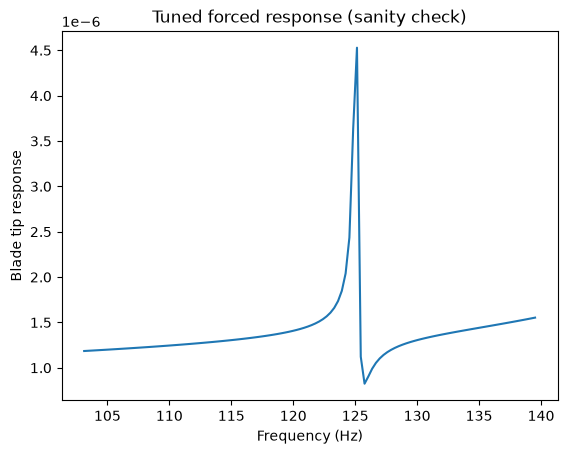

In [9]:
EO = 3                    # engine order of the forcing (traveling wave)
gamma_ave = 0.002         # tuned baseline structural damping

freqs = np.linspace(0.85 * tuned_freq[0], 1.15 * tuned_freq[0], 120)

F = np.zeros(n_rom, dtype=complex)
for n in range(N_SECTORS):
    F += np.exp(1j * EO * 2 * np.pi * n / N_SECTORS) * T_list[n][-1, :]  # force on blade tip dof

def forced_response(mB=None, mD=None, gB=None, gD=None):
    """Blade-tip response amplitude vs. frequency for the given mistuning.
    gB, gD are per-sector damping mistuning (added on top of gamma_ave)."""
    K = mistuned_K(mB, mD)
    C = np.zeros((n_rom, n_rom))
    if gB is not None:
        weights = gB * (1 + (mB if mB is not None else 0))
        C = C + np.tensordot(weights, blade_terms, axes=1)
    if gD is not None:
        weights = gD * (1 + (mD if mD is not None else 0))
        C = C + np.tensordot(weights, disk_terms, axes=1)

    resp = np.zeros(len(freqs))
    for i, f in enumerate(freqs):
        w = 2 * np.pi * f
        A = -w**2 * M_ROM + (1 + 1j * gamma_ave) * K + 1j * C
        x = np.linalg.solve(A, F)
        resp[i] = np.abs(x[-1])
    return resp

plt.figure()
plt.plot(freqs, forced_response())
plt.xlabel("Frequency (Hz)")
plt.ylabel("Blade tip response")
plt.title("Tuned forced response (sanity check)")
plt.savefig("results_tuned_response.png", dpi=150)
plt.show()

## 7. ML identification: stiffness-only, damping-only, combined

In [10]:
def make_dataset(n_samples, stiffness_on, damping_on,
                  sigma_k=0.02, damp_mean=0.002, damp_sigma=0.001):
    """Random blade mistuning patterns -> forced response curve (feature)
    and the mistuning values (label)."""
    X, Y = [], []
    for _ in range(n_samples):
        mB = np.random.normal(0, sigma_k, N_SECTORS) if stiffness_on else None
        gB = np.random.normal(damp_mean, damp_sigma, N_SECTORS) if damping_on else None
        resp = forced_response(mB=mB, gB=gB)
        X.append(resp)
        if stiffness_on and damping_on:
            Y.append(np.concatenate([mB, gB]))
        elif stiffness_on:
            Y.append(mB)
        else:
            Y.append(gB)
    return np.array(X), np.array(Y)


def run_case(name, stiffness_on, damping_on, n_samples=1500):
    print(f"\n=== {name} ===")
    X, Y = make_dataset(n_samples, stiffness_on, damping_on)
    Xtr, Xte, Ytr, Yte = train_test_split(X, Y, test_size=0.2, random_state=0)

    x_scaler = StandardScaler().fit(Xtr)
    y_scaler = StandardScaler().fit(Ytr)
    Xtr_s, Xte_s = x_scaler.transform(Xtr), x_scaler.transform(Xte)
    Ytr_s = y_scaler.transform(Ytr)

    model = MLPRegressor(hidden_layer_sizes=(64,), max_iter=2000, alpha=1e-2,
                          solver="adam", early_stopping=True, random_state=0)
    model.fit(Xtr_s, Ytr_s)

    pred = y_scaler.inverse_transform(model.predict(Xte_s))
    r2 = r2_score(Yte, pred)
    rmse = np.sqrt(np.mean((pred - Yte) ** 2))
    print(f"R2 = {r2:.4f}   RMSE = {rmse:.5f}")

    plt.figure(figsize=(5, 5))
    plt.scatter(Yte.flatten(), pred.flatten(), s=8, alpha=0.5)
    lims = [min(Yte.min(), pred.min()), max(Yte.max(), pred.max())]
    plt.plot(lims, lims, "r--")
    plt.xlabel("True mistuning")
    plt.ylabel("Predicted mistuning")
    plt.title(f"{name}  (R2={r2:.3f})")
    plt.tight_layout()
    plt.savefig(f"results_{name}.png", dpi=150)
    plt.show()
    return r2, rmse

### Case 1: stiffness mistuning only (damping tuned)


=== stiffness_only ===


R2 = 0.8368   RMSE = 0.00826


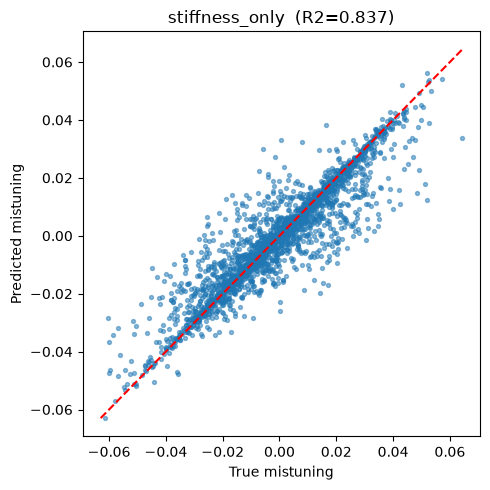

(0.8368370195060495, np.float64(0.008263334257211933))

In [11]:
run_case("stiffness_only", stiffness_on=True, damping_on=False)

### Case 2: damping mistuning only (stiffness tuned)


=== damping_only ===


R2 = 0.8601   RMSE = 0.00036


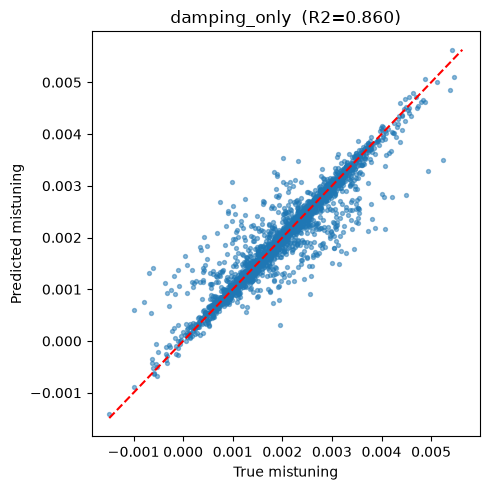

(0.8600766710057572, np.float64(0.000358902093217436))

In [12]:
run_case("damping_only", stiffness_on=False, damping_on=True)

### Case 3: stiffness and damping mistuning together


=== combined ===


R2 = 0.3778   RMSE = 0.00727


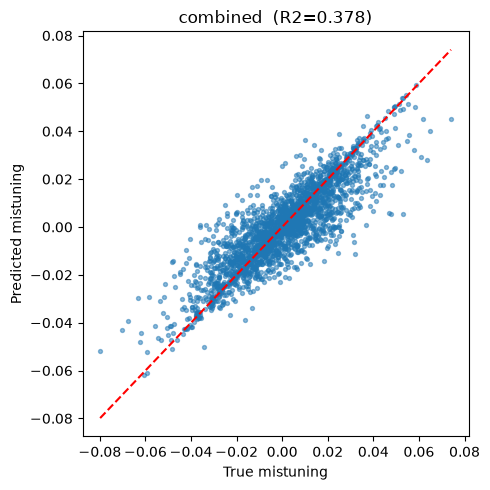

(0.3778381018305328, np.float64(0.0072728171254818315))

In [13]:
run_case("combined", stiffness_on=True, damping_on=True)